In [1]:
#imports 

import pandas as pd
import geobr
import matplotlib.pyplot as plt
import os

In [2]:
df = pd.read_parquet("../data/empreendimento-geracao-distribuida.parquet")

print(df.shape)           # linhas e colunas
print(df.columns.tolist())  # nomes das colunas
print(df.head())          # primeiras linhas
df.info()                 # tipos de dado e valores nulos

(4656839, 31)
['DatGeracaoConjuntoDados', 'AnmPeriodoReferencia', 'NumCNPJDistribuidora', 'SigAgente', 'NomAgente', 'CodClasseConsumo', 'DscClasseConsumo', 'CodSubGrupoTarifario', 'DscSubGrupoTarifario', 'CodUFibge', 'SigUF', 'CodRegiao', 'NomRegiao', 'CodMunicipioIbge', 'NomMunicipio', 'CodCEP', 'SigTipoConsumidor', 'NumCPFCNPJ', 'CodEmpreendimento', 'DthAtualizaCadastralEmpreend', 'SigModalidadeEmpreendimento', 'DscModalidadeHabilitado', 'QtdUCRecebeCredito', 'SigTipoGeracao', 'DscFonteGeracao', 'DscPorte', 'MdaPotenciaInstaladaKW', 'NomSubEstacao', 'NumCoordESub', 'NumCoordNSub', 'NomTitularEmpreendimento']
  DatGeracaoConjuntoDados AnmPeriodoReferencia  NumCNPJDistribuidora  \
0              2026-10-03              10/2026         4065033000170   
1              2026-10-03              10/2026         4065033000170   
2              2026-10-03              10/2026         4065033000170   
3              2026-10-03              10/2026         4065033000170   
4              2026-10

In [3]:
for col in df.columns:
    print(col)

DatGeracaoConjuntoDados
AnmPeriodoReferencia
NumCNPJDistribuidora
SigAgente
NomAgente
CodClasseConsumo
DscClasseConsumo
CodSubGrupoTarifario
DscSubGrupoTarifario
CodUFibge
SigUF
CodRegiao
NomRegiao
CodMunicipioIbge
NomMunicipio
CodCEP
SigTipoConsumidor
NumCPFCNPJ
CodEmpreendimento
DthAtualizaCadastralEmpreend
SigModalidadeEmpreendimento
DscModalidadeHabilitado
QtdUCRecebeCredito
SigTipoGeracao
DscFonteGeracao
DscPorte
MdaPotenciaInstaladaKW
NomSubEstacao
NumCoordESub
NumCoordNSub
NomTitularEmpreendimento


DthAtualizaCadastralEmpreend vai ser nosso eixo temporal, é o que a própria ANEEL usa nos seus gráficos.

Usinas desativadas somoem do dataset, tem que se ligar nisso se for extrair em momentos diferentes.

In [4]:
colunas = [
    "SigUF", #UF que foi coletado o dado
    "DscClasseConsumo", #Motivo da produção
    "DscSubGrupoTarifario",#Entender essas tarifas
    "SigTipoConsumidor", #Pessoa fisica ou juridica
    "DscModalidadeHabilitado", # ainda nao sei
    "SigTipoGeracao", #ainda nao sei
    "DscFonteGeracao", #O que gera a energia
    "DscPorte", #Porte da geração
]

for col in colunas:
    if col in df.columns:
        print(f"\n=== {col} ({df[col].nunique()} valores únicos) ===")
        print(df[col].value_counts(dropna=False))
    else:
        print(f"\n!!! Coluna '{col}' não existe no arquivo")


=== SigUF (27 valores únicos) ===
SigUF
SP     787146
MG     484962
RS     431429
PR     335748
BA     327547
MT     239151
RJ     201636
SC     200065
GO     186780
MS     175164
PE     172125
PA     162478
CE     152724
RN     124096
ES     109781
MA      97462
PI      90528
RO      66766
TO      65914
AL      57243
PB      56587
DF      35996
SE      27449
AM      25944
AC      19326
AP      13894
RR       8897
NaN         1
Name: count, dtype: int64

=== DscClasseConsumo (10 valores únicos) ===
DscClasseConsumo
Residencial           3726947
Comercial              420370
Rural                  392830
Industrial              57228
REBR                    45675
Poder Público           13101
Serviço Público           410
Iluminação pública        232
Consumo Próprio            45
REBR                        1
Name: count, dtype: int64

=== DscSubGrupoTarifario (11 valores únicos) ===
DscSubGrupoTarifario
B1     3759435
B3      452550
B2      394285
A4       39364
AS        4031
A3a   

Separei aqui algumas colunas importantes, tem alguns outliers que tem que se ligar de remover no pré-processamento.

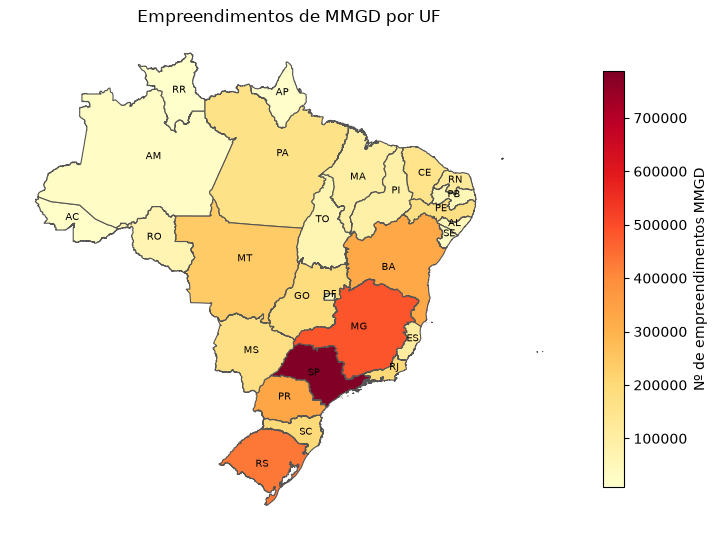

In [7]:
contagem = df["SigUF"].value_counts().rename("qtd").reset_index()
contagem.columns = ["abbrev_state", "qtd"]

estados = geobr.read_state(year=2020)
mapa = estados.merge(contagem, on="abbrev_state", how="left")

fig, ax = plt.subplots(figsize=(9, 9))
mapa.plot(
    ax=ax,
    column="qtd",
    cmap="YlOrRd",
    edgecolor="#555555",
    linewidth=0.8,
    legend=True,
    legend_kwds={"label": "Nº de empreendimentos MMGD", "shrink": 0.6},
)

for _, row in mapa.iterrows():
    p = row.geometry.representative_point()
    ax.annotate(row["abbrev_state"], (p.x, p.y), ha="center", fontsize=7)

ax.set_title("Empreendimentos de MMGD por UF")
ax.axis("off")
os.makedirs("../resultados", exist_ok=True)
plt.savefig("../resultados/mapa_mmgd_uf.png", dpi=200, bbox_inches="tight")
plt.show()